# SHAP-IMV — Adult Income

Exact Shapley attribution with IMV as the coalition value, on the UCI Adult
Income census extract (binary: income > 50K).

**Pipeline**: download from UCI → preprocess → standardise → 10 seeds × 3
estimators × exact power set → aggregate.

No data is committed; `fetch_ucirepo` downloads into a user-level cache.
Full documentation: `documentation/examples/shap_imv/adult_income.md`.

In [1]:
import os, sys, tempfile, warnings, itertools
from pathlib import Path

_PATH_DISPLAY_ROOT = Path()

def relative_path(path, *, start=None):
    """Return a display-only path relative to an explicit local anchor."""
    anchor = Path(start) if start is not None else _PATH_DISPLAY_ROOT
    try:
        relative = os.path.relpath(Path(path).expanduser().resolve(),
                                   start=anchor.expanduser().resolve())
    except ValueError:  # Paths on different Windows drives cannot be relativized.
        relative = Path(path).name
    return Path(relative).as_posix()

def _relative_warning_text(message):
    text = str(message)
    roots = {Path.home(), Path(sys.prefix), Path(sys.base_prefix),
             _PATH_DISPLAY_ROOT, Path(tempfile.gettempdir())}
    for root in sorted(roots, key=lambda value: len(str(value)), reverse=True):
        absolute = str(root.expanduser().resolve())
        text = text.replace(absolute, relative_path(absolute))
    return text

def _show_relative_warning(message, category, filename, lineno, file=None, line=None):
    stream = file if file is not None else sys.stderr
    warning_text = _relative_warning_text(message)
    print(f"{relative_path(filename)}:{lineno}: {category.__name__}: {warning_text}", file=stream)

warnings.showwarning = _show_relative_warning

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# No dataset is stored in this repository. Everything downloads on demand into a
# user-level cache outside the working tree.
CACHE = Path(os.environ.get("IMV_CACHE_HOME", Path.home() / ".cache" / "imv"))
CACHE.mkdir(parents=True, exist_ok=True)

ARTIFACTS = Path(os.environ.get("IMV_ARTIFACT_CACHE", CACHE / "notebook_artifacts")) / "shap_imv_adult_income"
RESULTS = ARTIFACTS / "results"; RESULTS.mkdir(parents=True, exist_ok=True)
FIGURES = ARTIFACTS / "figures"; FIGURES.mkdir(parents=True, exist_ok=True)

# Ten seeds, as required for any reported IMV result. The seed drives the fold
# split and the estimator, so every number below is a mean over ten independent
# fold partitions.
SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
N_SPLITS = 5

import imv
from imv import BinaryIMV
from imv.utils import save_figure

# Fail fast if Jupyter is attached to a different installation of imv.
_HERE = Path().resolve()
REPOSITORY_ROOT = next((path for path in (_HERE, *_HERE.parents)
                        if (path / "pyproject.toml").is_file()
                        and (path / "src" / "imv").is_dir()), None)
if REPOSITORY_ROOT is None:
    raise RuntimeError("Run this notebook from inside the imv repository checkout.")
_PATH_DISPLAY_ROOT = REPOSITORY_ROOT
IMV_SOURCE = Path(imv.__file__).resolve().parent
EXPECTED_IMV_SOURCE = (REPOSITORY_ROOT / "src" / "imv").resolve()
if IMV_SOURCE != EXPECTED_IMV_SOURCE:
    raise RuntimeError("Expected repository package at "
                       f"{relative_path(EXPECTED_IMV_SOURCE)}, imported "
                       f"{relative_path(IMV_SOURCE)}")
print(f"imv {imv.__version__} from {relative_path(IMV_SOURCE)}")


imv 1.2.0 from src/imv


## 1. Download

Nothing is read from the repository.

In [2]:
from ucimlrepo import fetch_ucirepo
DATASET, TITLE = "adult_income", "Adult Income"
raw = fetch_ucirepo(id=2)
frame = raw.data.features.copy()
frame["target"] = raw.data.targets.iloc[:, 0].astype(str).str.strip().str.rstrip(".")
print(frame.shape, frame["target"].value_counts().to_dict())
frame.head()

(48842, 15) {'<=50K': 37155, '>50K': 11687}


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2. Preprocess

Every transformation is applied here and stated in the docs.

In [3]:
# Binary target, then six features chosen to span demographic, human-capital and
# labour-supply signal while keeping 2**6 = 64 coalitions affordable.
frame["target"] = (frame["target"] == ">50K").astype(int)
FEATURES = ["age", "education-num", "hours-per-week", "capital-gain",
            "sex_female", "married"]
frame["sex_female"] = (frame["sex"].astype(str).str.strip() == "Female").astype(int)
frame["married"] = frame["marital-status"].astype(str).str.strip().str.startswith("Married").astype(int)
data = frame[FEATURES + ["target"]].apply(pd.to_numeric, errors="coerce").dropna()
print(data.shape, "positive rate:", round(data["target"].mean(), 4))
data.head()

(48842, 7) positive rate: 0.2393


,age,education-num,hours-per-week,capital-gain,sex_female,married,target
0,39,13,40,2174,0,0,0
1,50,13,13,0,0,1,0
2,38,9,40,0,0,0,0
3,53,7,40,0,0,1,0
4,28,13,40,0,1,1,0


## 3. Estimators and budget

In [4]:
# Exact SHAP-IMV enumerates every feature subset, so cost is
# 2**n_features * n_splits * 2 fits per seed per estimator. Rows are capped at
# 4000 (stratified, seeded) to keep that affordable; this is an example budget,
# not a methodological recommendation.
MAX_ROWS = 4000

def subsample(frame, target, seed):
    if len(frame) <= MAX_ROWS:
        return frame.reset_index(drop=True)
    frac = MAX_ROWS / len(frame)
    out = frame.groupby(target, group_keys=False).sample(
        frac=frac, random_state=seed
    )
    return out.reset_index(drop=True)

def model_factories(seed):
    """Three estimator families, deliberately small so the exact power set is affordable."""
    return {
        "logistic_regression": lambda: LogisticRegression(max_iter=5000, random_state=seed),
        "xgboost": lambda: XGBClassifier(
            n_estimators=60, max_depth=3, learning_rate=0.2, random_state=seed,
            verbosity=0, tree_method="hist", n_jobs=1),
        "lightgbm": lambda: LGBMClassifier(
            n_estimators=60, max_depth=3, learning_rate=0.2, random_state=seed,
            verbose=-1, n_jobs=1),
    }


## 4. Exact SHAP-IMV over ten seeds

Each value is a mean over ten independent fold partitions; `std` is the spread across seeds, which describes stability and is **not** a confidence interval.

In [5]:
# Features are standardised because IMV reads probabilities, and unscaled inputs
# leave logistic regression unconverged, which would score a half-optimised model.
def scaled(frame, features):
    out = frame.copy()
    out[features] = StandardScaler().fit_transform(out[features])
    return out

records = []
for seed in SEEDS:
    frame = scaled(subsample(data, "target", seed), FEATURES)
    for name, factory in model_factories(seed).items():
        evaluator = BinaryIMV(
            frame, "target", FEATURES, factory,
            split_method="stratified_kfold", n_splits=N_SPLITS,
            random_seed=seed, n_jobs=1,
        )
        evaluator.run_evaluation()
        for feature in FEATURES:
            records.append({
                "seed": seed, "model": name, "feature": feature,
                "shap_imv": evaluator.calculate_imvshapley_value(feature),
            })
        records.append({
            "seed": seed, "model": name, "feature": "__full_model_imv__",
            "shap_imv": evaluator.all_combinations_imv[tuple(FEATURES)][0],
        })

raw = pd.DataFrame(records)
raw.to_csv(RESULTS / f"{DATASET}_shap_imv_by_seed.csv", index=False)
summary = (raw[raw.feature != "__full_model_imv__"]
           .groupby(["model", "feature"])["shap_imv"]
           .agg(["mean", "std"]).reset_index()
           .sort_values(["model", "mean"], ascending=[True, False]))
summary.to_csv(RESULTS / f"{DATASET}_shap_imv_summary.csv", index=False)
summary


  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

...

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

,model,feature,mean,std
4,lightgbm,married,0.0539,0.001792
1,lightgbm,capital-gain,0.0460,0.003972
2,lightgbm,education-num,0.0354,0.003688
0,lightgbm,age,0.0262,0.001687
3,lightgbm,hours-per-week,0.0135,0.002953
5,lightgbm,sex_female,0.0097,0.001418
10,logistic_regression,married,0.0602,0.001989
8,logistic_regression,education-num,0.0421,0.005259
7,logistic_regression,capital-gain,0.0338,0.003120
6,logistic_regression,age,0.0131,0.001853


## 5. Figure

A negative bar means the feature *reduced* held-out information — it does not indicate the negative class.

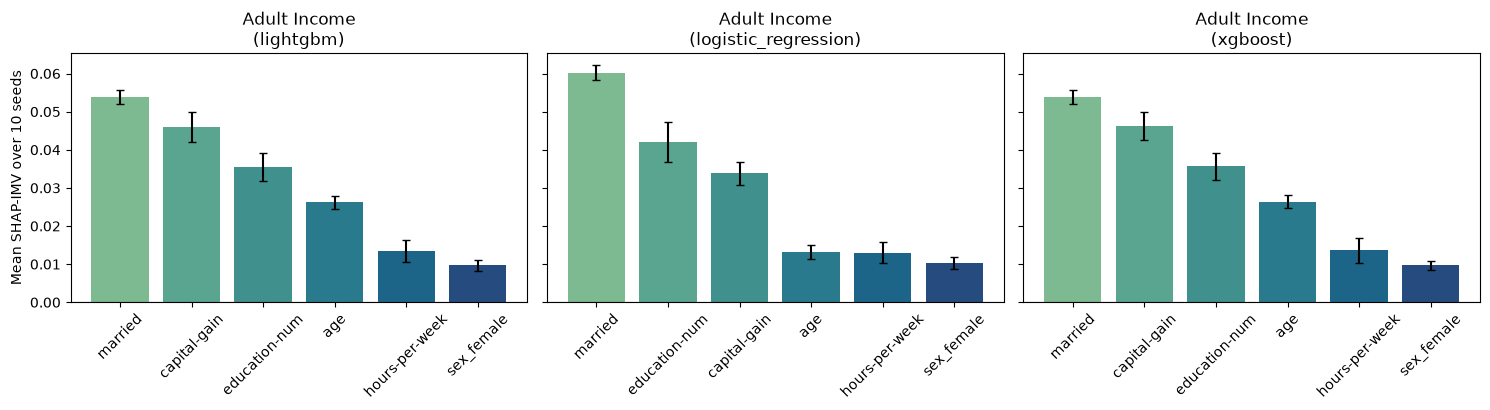

{'png': 'figures/adult_income_shap_imv.png',
 'pdf': 'figures/adult_income_shap_imv.pdf',
 'svg': 'figures/adult_income_shap_imv.svg'}

In [6]:
models = list(summary["model"].unique())
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4.2), sharey=True)
axes = np.atleast_1d(axes)
for ax, name in zip(axes, models):
    part = summary[summary.model == name].sort_values("mean", ascending=False)
    ax.bar(part["feature"], part["mean"], yerr=part["std"].fillna(0),
           capsize=3, color=sns.color_palette("crest", len(part)))
    ax.set_title(f"{TITLE}\n({name})")
    ax.tick_params(axis="x", rotation=45)
    ax.axhline(0, color="0.4", linewidth=0.8)
axes[0].set_ylabel(f"Mean SHAP-IMV over {len(SEEDS)} seeds")
fig.tight_layout()
paths = {file_format: relative_path(path, start=ARTIFACTS)
         for file_format, path in save_figure(
             fig, FIGURES / f"{DATASET}_shap_imv"
         ).items()}
plt.show()
paths
